# 6.5 Laboratório: Modelos lineares e métodos de regularização

Este notebook traduz e organiza o trecho do laboratório do Capítulo 6.

A sequência segue o texto original: seleção de subconjuntos, seleção forward, validação cruzada, melhor subconjunto, regressão ridge, lasso, PCR e PLS.

O foco é manter a didática do capítulo e deixar o código executável.

## Importações iniciais

Começamos importando as bibliotecas usadas no laboratório. Elas serão usadas para manipulação de dados, regressão, validação cruzada, padronização, pipelines, PCA, PLS e seleção de modelos.

In [2]:
import numpy as np
import pandas as pd

from matplotlib.pyplot import subplots
from statsmodels.api import OLS

import sklearn.model_selection as skm
import sklearn.linear_model as skl

from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.cross_decomposition import PLSRegression

from ISLP import load_data
from ISLP.models import ModelSpec as MS
from ISLP.models import Stepwise, sklearn_selected, sklearn_selection_path

from functools import partial

O pacote `l0bnb` é usado para seleção do melhor subconjunto. Caso não esteja instalado no ambiente, execute a célula abaixo.

In [4]:
# %pip install -q ISLP l0bnb
from l0bnb import fit_path


# 6.5.1 Métodos de seleção de subconjuntos

Nesta seção, implementamos métodos que reduzem o número de parâmetros do modelo restringindo o ajuste a um subconjunto das variáveis de entrada.

A ideia é não usar todos os preditores disponíveis, mas escolher um grupo menor que mantenha bom desempenho.

## Seleção forward

Aplicamos seleção forward ao conjunto `Hitters`.

O objetivo é prever `Salary`, o salário de um jogador de beisebol, usando estatísticas de desempenho do ano anterior.

Primeiro verificamos valores ausentes em `Salary`. A função `np.isnan()` identifica ausências, e `.sum()` conta quantas existem.

In [5]:
Hitters = load_data('Hitters')
np.isnan(Hitters['Salary']).sum()

np.int64(59)

O resultado esperado é 59 valores ausentes em `Salary`.

Agora removemos linhas com valores faltantes usando `dropna()`.

In [6]:
Hitters = Hitters.dropna()
Hitters.shape

(263, 20)

Depois da remoção, restam 263 observações e 20 colunas.

Agora escolhemos o melhor modelo por seleção forward usando o critério \(C_p\). Como \(C_p\) não vem pronto no `sklearn`, definimos uma função própria.

Como o `sklearn` maximiza pontuações, calculamos o negativo de \(C_p\). Maximizar \(-C_p\) equivale a minimizar \(C_p\).

In [7]:
def nCp(sigma2, estimator, X, Y):
    # Estatística Cp negativa.
    n, p = X.shape
    Yhat = estimator.predict(X)
    RSS = np.sum((Y - Yhat) ** 2)
    return -(RSS + 2 * p * sigma2) / n

Para calcular \(C_p\), precisamos estimar a variância residual \(\sigma^2\). Fazemos isso ajustando o maior modelo, com todas as variáveis.

In [8]:
design = MS(Hitters.columns.drop('Salary')).fit(Hitters)

Y = np.array(Hitters['Salary'])
X = design.transform(Hitters)

sigma2 = OLS(Y, X).fit().scale
sigma2

np.float64(99591.35617968219)

A função `sklearn_selected()` espera uma função de pontuação com três argumentos. Como `nCp()` também precisa de \(\sigma^2\), usamos `partial()` para fixar esse argumento.

In [9]:
neg_Cp = partial(nCp, sigma2)

Agora definimos a estratégia de seleção forward.

O método `Stepwise.first_peak()` executa a seleção até que adicionar novas variáveis deixe de melhorar a pontuação.

In [10]:
strategy = Stepwise.first_peak(
    design,
    direction='forward',
    max_terms=len(design.terms)
)

Primeiro ajustamos a seleção forward sem especificar \(C_p\). Nesse caso, a métrica padrão é o MSE.

In [11]:
hitters_MSE = sklearn_selected(OLS, strategy)
hitters_MSE.fit(Hitters, Y)
hitters_MSE.selected_state_

('Assists',
 'AtBat',
 'CAtBat',
 'CHits',
 'CHmRun',
 'CRBI',
 'CRuns',
 'CWalks',
 'Division',
 'Errors',
 'Hits',
 'HmRun',
 'League',
 'NewLeague',
 'PutOuts',
 'RBI',
 'Runs',
 'Walks',
 'Years')

Agora usamos o \(C_p\) negativo como critério. Como esperado, o modelo selecionado fica menor.

In [12]:
hitters_Cp = sklearn_selected(
    OLS,
    strategy,
    scoring=neg_Cp
)

hitters_Cp.fit(Hitters, Y)
hitters_Cp.selected_state_

('Assists',
 'AtBat',
 'CAtBat',
 'CRBI',
 'CRuns',
 'CWalks',
 'Division',
 'Hits',
 'PutOuts',
 'Walks')

No trecho do livro, o modelo selecionado por \(C_p\) contém 10 variáveis. Isso conecta o laboratório à teoria: critérios como \(C_p\) penalizam modelos grandes para equilibrar ajuste e complexidade.

## Escolha entre modelos por validação e validação cruzada

Em vez de escolher por \(C_p\), podemos usar validação cruzada para selecionar o tamanho do modelo na seleção forward.

Para isso, precisamos guardar o caminho completo de modelos encontrados pela seleção forward: modelo nulo, modelo com uma variável, modelo com duas variáveis, e assim por diante.

O estimador `sklearn_selection_path()` faz esse armazenamento.

In [14]:
strategy = Stepwise.fixed_steps(
    design,
    len(design.terms),
    direction='forward'
)

full_path = sklearn_selection_path(OLS, strategy)

Ajustamos o caminho completo nos dados `Hitters` e calculamos as previsões dentro da amostra.

In [15]:
full_path.fit(Hitters, Y)
Yhat_in = full_path.predict(Hitters)
Yhat_in.shape

(263, 20)

A matriz de previsões tem 20 etapas: o modelo nulo e os 19 passos de inclusão de variáveis.

O MSE dentro da amostra tende a cair a cada nova variável adicionada. Isso não prova melhor generalização, apenas melhor ajuste ao treino.

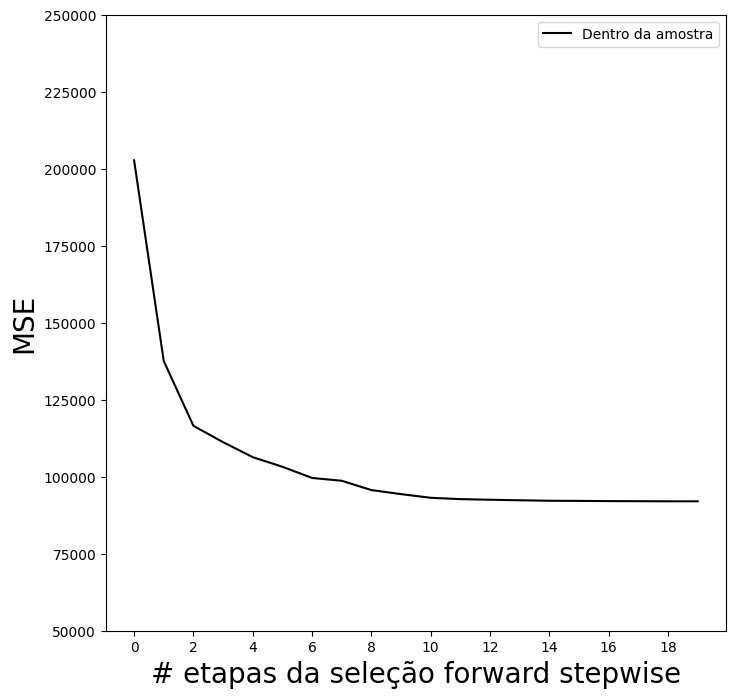

In [16]:
mse_fig, ax = subplots(figsize=(8, 8))

insample_mse = ((Yhat_in - Y[:, None]) ** 2).mean(0)
n_steps = insample_mse.shape[0]

ax.plot(
    np.arange(n_steps),
    insample_mse,
    'k',
    label='Dentro da amostra'
)

ax.set_ylabel('MSE', fontsize=20)
ax.set_xlabel('# etapas da seleção forward stepwise', fontsize=20)
ax.set_xticks(np.arange(n_steps)[::2])
ax.legend()
ax.set_ylim([50000, 250000]);

A expressão `Y[:, None]` adiciona uma dimensão ao vetor `Y`, permitindo a subtração com a matriz `Yhat_in`.

Agora usamos validação cruzada com 5 dobras. O ponto técnico central é que a seleção de variáveis também precisa ocorrer dentro de cada dobra de treinamento. Se a seleção for feita usando todos os dados, o erro de validação cruzada fica otimista.

In [17]:
K = 5

kfold = skm.KFold(
    K,
    random_state=0,
    shuffle=True
)

Yhat_cv = skm.cross_val_predict(
    full_path,
    Hitters,
    Y,
    cv=kfold
)

Yhat_cv.shape

(263, 20)

Agora calculamos o MSE em cada dobra e em cada etapa do caminho de seleção.

In [18]:
cv_mse = []

for train_idx, test_idx in kfold.split(Y):
    errors = (Yhat_cv[test_idx] - Y[test_idx, None]) ** 2
    cv_mse.append(errors.mean(0))

cv_mse = np.array(cv_mse).T
cv_mse.shape

(20, 5)

Adicionamos ao gráfico o erro médio de validação cruzada e uma estimativa do erro-padrão.

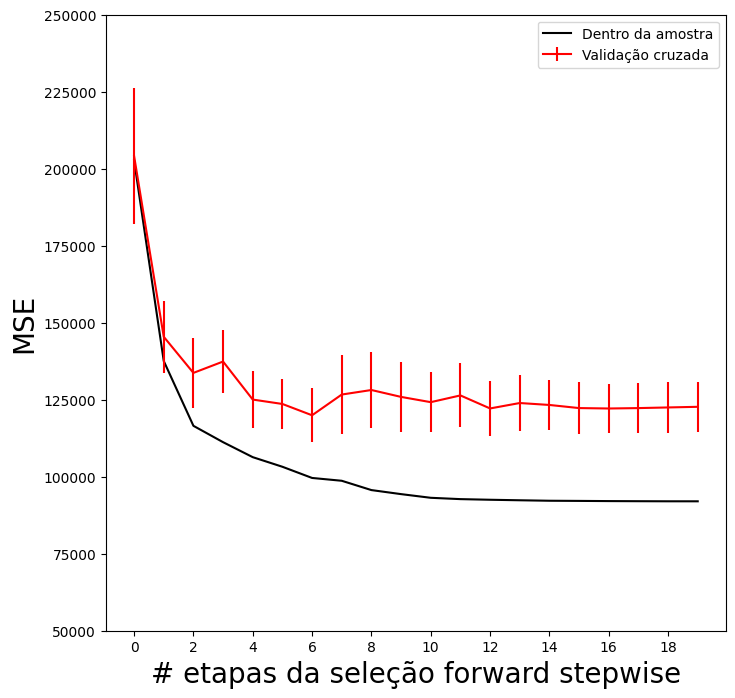

In [19]:
ax.errorbar(
    np.arange(n_steps),
    cv_mse.mean(1),
    cv_mse.std(1) / np.sqrt(K),
    label='Validação cruzada',
    c='r'
)

ax.set_ylim([50000, 250000])
ax.legend()
mse_fig

Para repetir com o método do conjunto de validação, usamos uma única divisão aleatória entre treino e validação. Aqui, 20% dos dados ficam no conjunto de validação.

In [20]:
validation = skm.ShuffleSplit(
    n_splits=1,
    test_size=0.2,
    random_state=0
)

for train_idx, test_idx in validation.split(Y):
    full_path.fit(Hitters.iloc[train_idx], Y[train_idx])
    Yhat_val = full_path.predict(Hitters.iloc[test_idx])
    errors = (Yhat_val - Y[test_idx, None]) ** 2
    validation_mse = errors.mean(0)

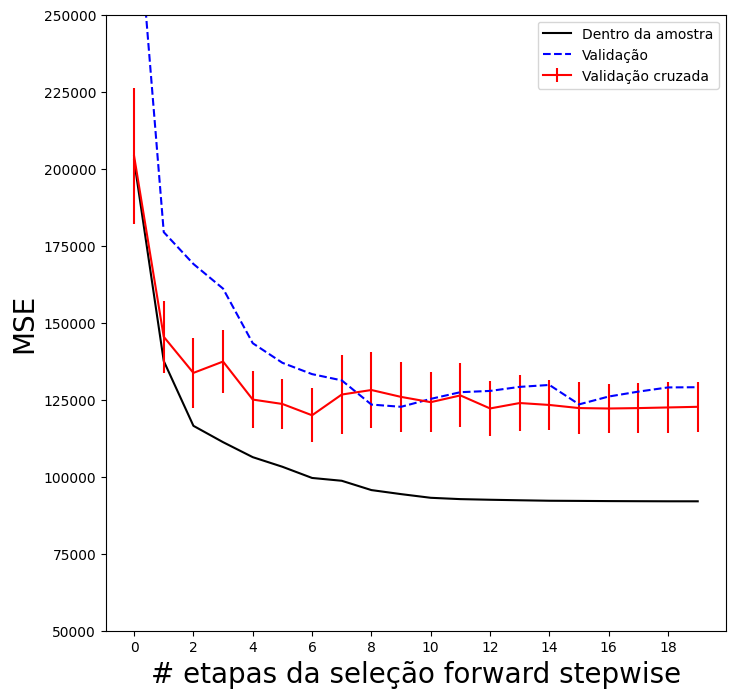

In [21]:
ax.plot(
    np.arange(n_steps),
    validation_mse,
    'b--',
    label='Validação'
)

ax.set_xticks(np.arange(n_steps)[::2])
ax.set_ylim([50000, 250000])
ax.legend()
mse_fig

## Seleção do melhor subconjunto

A seleção forward stepwise é gananciosa: em cada etapa, adiciona uma variável ao conjunto atual.

A seleção do melhor subconjunto, por outro lado, busca o melhor conjunto de preditores para cada tamanho de modelo.

Usaremos o pacote `l0bnb`. Ele produz um caminho de soluções usando o tamanho do subconjunto como penalidade.

In [22]:
D = design.fit_transform(Hitters)
D = D.drop('intercept', axis=1)

X = np.asarray(D)

Removemos a coluna do intercepto, pois `l0bnb` ajusta o intercepto separadamente.

In [24]:
np.Inf = np.inf

from l0bnb import fit_path

path = fit_path(
    X,
    Y,
    max_nonzeros=X.shape[1]
)

Preprocessing Data.
BnB Started.
Iteration: 1. Number of non-zeros:  1
Iteration: 2. Number of non-zeros:  2
Iteration: 3. Number of non-zeros:  2
Iteration: 4. Number of non-zeros:  2
Iteration: 5. Number of non-zeros:  3
Iteration: 6. Number of non-zeros:  3
Iteration: 7. Number of non-zeros:  4
Iteration: 8. Number of non-zeros:  9
Iteration: 9. Number of non-zeros:  9
Iteration: 10. Number of non-zeros:  9
Iteration: 11. Number of non-zeros:  9
Iteration: 12. Number of non-zeros:  9
Iteration: 13. Number of non-zeros:  9
Iteration: 14. Number of non-zeros:  9
Iteration: 15. Number of non-zeros:  9
Iteration: 16. Number of non-zeros:  9
Iteration: 17. Number of non-zeros:  9
Iteration: 18. Number of non-zeros:  17
Iteration: 19. Number of non-zeros:  19


Cada item de `path` contém coeficientes (`B`), intercepto (`B0`) e informações internas do algoritmo.

In [25]:
path[3]

{'B': array([0.        , 3.25484367, 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.67775265, 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        ]),
 'B0': np.float64(-38.98216739555505),
 'lambda_0': np.float64(0.011416248027450187),
 'M': np.float64(0.5829861733382012),
 'Time_exceeded': False}

# 6.5.2 Regressão ridge e lasso

Agora ajustamos modelos lineares regularizados ridge e lasso usando `sklearn.linear_model`.

Partimos da matriz \(X\) sem intercepto, construída na seção anterior.

## Regressão ridge

Usaremos `skl.ElasticNet()` para ajustar ridge e lasso.

A regressão ridge corresponde a:

\[
\text{l1\_ratio} = 0
\]

Como as variáveis podem estar em escalas diferentes, padronizamos \(X\).

In [26]:
Xs = X - X.mean(0)[None, :]
X_scale = X.std(0)
Xs = Xs / X_scale[None, :]

lambdas = 10 ** np.linspace(8, -2, 100) / Y.std()

soln_array = skl.ElasticNet.path(
    Xs,
    Y,
    l1_ratio=0.,
    alphas=lambdas
)[1]

soln_array.shape

c:\Users\daler\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:701: UserWarning: Coordinate descent without L1 regularization may lead to unexpected results and is discouraged. Set l1_ratio > 0 to add L1 regularization.
  model = cd_fast.enet_coordinate_descent_gram(
c:\Users\daler\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 6.443e+07, tolerance: 1.289e+04
  model = cd_fast.enet_coordinate_descent_gram(
c:\Users\daler\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:701: UserWarning: Coordinate descent without L1 regularization may lead to unexpected results and is discouraged. Set l1_ratio > 0 to add L1 regularization.
  model = cd_fast

(19, 100)

A matriz `soln_array` contém os coeficientes ridge para 100 valores de \(\lambda\). Ela tem 19 linhas, uma por preditor, e 100 colunas, uma por valor de \(\lambda\).

In [27]:
soln_path = pd.DataFrame(
    soln_array.T,
    columns=D.columns,
    index=-np.log(lambdas)
)

soln_path.index.name = 'negative log(lambda)'
soln_path

,AtBat,Hits,HmRun,Runs,RBI,Walks,Years,CAtBat,CHits,CHmRun,CRuns,CRBI,CWalks,League[N],Division[W],PutOuts,Assists,Errors,NewLeague[N]
negative log(lambda),,,,,,,,,,,,,,,,,,,
-12.310855,0.000800,0.000889,0.000695,0.000851,0.000911,0.000900,0.000812,0.001067,0.001113,0.001064,0.001141,0.001149,0.000993,-0.000029,-0.000390,0.000609,0.000052,-0.000011,-0.000006
-12.078271,0.001010,0.001122,0.000878,0.001074,0.001150,0.001135,0.001025,0.001346,0.001404,0.001343,0.001439,0.001450,0.001253,-0.000037,-0.000492,0.000769,0.000065,-0.000014,-0.000007
-11.845686,0.001274,0.001416,0.001107,0.001355,0.001451,0.001433,0.001293,0.001698,0.001772,0.001694,0.001816,0.001830,0.001581,-0.000046,-0.000621,0.000970,0.000082,-0.000017,-0.000009
-11.613102,0.001608,0.001787,0.001397,0.001710,0.001831,0.001808,0.001632,0.002143,0.002236,0.002138,0.002292,0.002309,0.001995,-0.000058,-0.000784,0.001224,0.000104,-0.000022,-0.000012
-11.380518,0.002029,0.002255,0.001763,0.002158,0.002310,0.002281,0.002059,0.002704,0.002821,0.002698,0.002892,0.002914,0.002517,-0.000073,-0.000990,0.001544,0.000131,-0.000028,-0.000015
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9.784658,-290.823989,336.929968,37.322686,-59.748520,-26.507086,134.855915,-17.216195,-387.775826,89.573601,-12.273926,476.079273,257.271255,-213.124780,31.258215,-58.457857,78.761266,53.622113,-22.208456,-12.402891
10.017243,-290.879272,337.113713,37.431373,-59.916820,-26.606957,134.900549,-17.108041,-388.458404,89.000707,-12.661459,477.031349,257.966790,-213.280891,31.256434,-58.448850,78.761240,53.645147,-22.198802,-12.391969
10.249827,-290.923382,337.260446,37.518064,-60.051166,-26.686604,134.936136,-17.022194,-388.997470,88.537380,-12.971603,477.791860,258.523025,-213.405740,31.254958,-58.441682,78.761230,53.663357,-22.191071,-12.383205


Plotamos os caminhos dos coeficientes.

O eixo horizontal mostra:

\[
-\log(\lambda)
\]

Da esquerda para a direita, \(\lambda\) diminui e a regularização fica mais fraca.

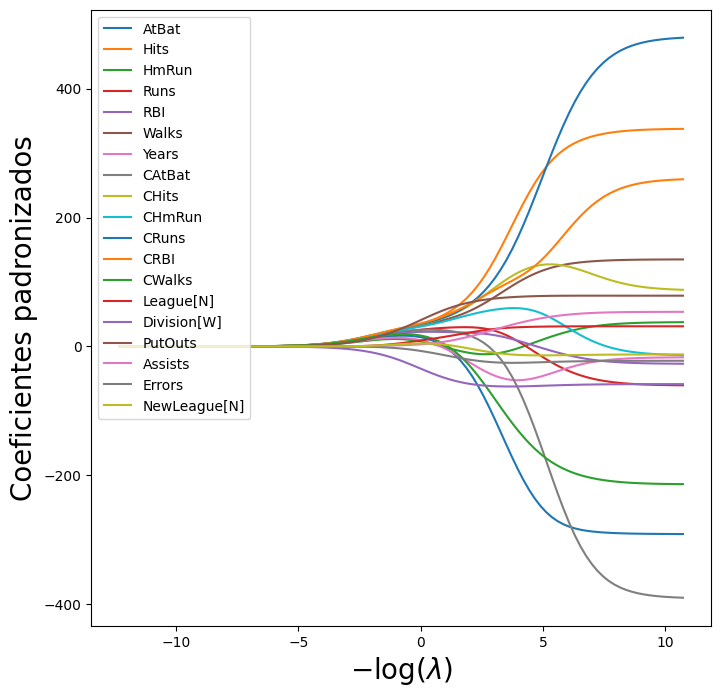

In [28]:
path_fig, ax = subplots(figsize=(8, 8))

soln_path.plot(ax=ax, legend=False)

ax.set_xlabel(r'$-\log(\lambda)$', fontsize=20)
ax.set_ylabel('Coeficientes padronizados', fontsize=20)
ax.legend(loc='upper left');

A norma \(\ell_2\) dos coeficientes é:

\[
\|\beta\|_2 =
\sqrt{\sum_{j=1}^{p}\beta_j^2}
\]

Ela mede o tamanho global do vetor de coeficientes.

In [29]:
beta_hat = soln_path.loc[soln_path.index[39]]

lambdas[39], beta_hat

(np.float64(25.53538897200662),
 AtBat           5.433750
 Hits            6.223582
 HmRun           4.585498
 Runs            5.880855
 RBI             6.195921
 Walks           6.277975
 Years           5.299767
 CAtBat          7.147501
 CHits           7.539495
 CHmRun          7.182344
 CRuns           7.728649
 CRBI            7.790702
 CWalks          6.592901
 League[N]       0.042445
 Division[W]    -3.107159
 PutOuts         4.605263
 Assists         0.378371
 Errors         -0.135196
 NewLeague[N]    0.150323
 Name: -3.240065292879872, dtype: float64)

In [30]:
np.linalg.norm(beta_hat)

np.float64(24.17061720144378)

Agora usamos um \(\lambda\) menor. Como a penalização é mais fraca, a norma dos coeficientes aumenta.

In [31]:
beta_hat = soln_path.loc[soln_path.index[59]]

lambdas[59], np.linalg.norm(beta_hat)

(np.float64(0.24374766133488554), np.float64(160.42371017725918))

A mesma padronização pode ser feita com uma `Pipeline()`, separando a etapa de escala da etapa de ajuste ridge.

In [32]:
ridge = skl.ElasticNet(alpha=lambdas[59], l1_ratio=0)

scaler = StandardScaler(with_mean=True, with_std=True)

pipe = Pipeline(
    steps=[
        ('scaler', scaler),
        ('ridge', ridge)
    ]
)

pipe.fit(X, Y)
np.linalg.norm(ridge.coef_)

c:\Users\daler\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.446e+07, tolerance: 5.332e+03
Linear regression models with a zero l1 penalization strength are more efficiently fitted using one of the solvers implemented in sklearn.linear_model.Ridge/RidgeCV instead.
  model = cd_fast.enet_coordinate_descent(


np.float64(160.42371017725927)

## Estimando erro de teste da regressão ridge

Escolher \(\lambda\) arbitrariamente é ruim. Usamos validação ou validação cruzada para selecionar esse parâmetro.

In [33]:
validation = skm.ShuffleSplit(
    n_splits=1,
    test_size=0.5,
    random_state=0
)

ridge.alpha = 0.01

results = skm.cross_validate(
    ridge,
    X,
    Y,
    scoring='neg_mean_squared_error',
    cv=validation
)

-results['test_score']

c:\Users\daler\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.486e+06, tolerance: 2.272e+03
Linear regression models with a zero l1 penalization strength are more efficiently fitted using one of the solvers implemented in sklearn.linear_model.Ridge/RidgeCV instead.
  model = cd_fast.enet_coordinate_descent(


array([134214.00419204])

Agora usamos um valor muito grande de \(\lambda\), aproximando um modelo nulo.

In [34]:
ridge.alpha = 1e10

results = skm.cross_validate(
    ridge,
    X,
    Y,
    scoring='neg_mean_squared_error',
    cv=validation
)

-results['test_score']

c:\Users\daler\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.136e+07, tolerance: 2.272e+03
Linear regression models with a zero l1 penalization strength are more efficiently fitted using one of the solvers implemented in sklearn.linear_model.Ridge/RidgeCV instead.
  model = cd_fast.enet_coordinate_descent(


array([231788.32155285])

Usamos `GridSearchCV()` para escolher \(\lambda\) por busca em grade.

In [35]:
param_grid = {'ridge__alpha': lambdas}

grid = skm.GridSearchCV(
    pipe,
    param_grid,
    cv=validation,
    scoring='neg_mean_squared_error'
)

grid.fit(X, Y)

grid.best_params_['ridge__alpha'], grid.best_estimator_

c:\Users\daler\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.136e+07, tolerance: 2.272e+03
Linear regression models with a zero l1 penalization strength are more efficiently fitted using one of the solvers implemented in sklearn.linear_model.Ridge/RidgeCV instead.
  model = cd_fast.enet_coordinate_descent(
c:\Users\daler\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.136e+07, tolerance: 2.272e+03
Linear regression models with a zero l1 penalization strength are more efficiently fitted using one of th

(np.float64(0.005899006046740856),
 Pipeline(steps=[('scaler', StandardScaler()),
                 ('ridge',
                  ElasticNet(alpha=np.float64(0.005899006046740856),
                             l1_ratio=0))]))

Agora usamos validação cruzada com 5 dobras.

In [36]:
grid = skm.GridSearchCV(
    pipe,
    param_grid,
    cv=kfold,
    scoring='neg_mean_squared_error'
)

grid.fit(X, Y)

grid.best_params_['ridge__alpha'], grid.best_estimator_

c:\Users\daler\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.880e+07, tolerance: 3.759e+03
Linear regression models with a zero l1 penalization strength are more efficiently fitted using one of the solvers implemented in sklearn.linear_model.Ridge/RidgeCV instead.
  model = cd_fast.enet_coordinate_descent(
c:\Users\daler\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.101e+07, tolerance: 4.201e+03
Linear regression models with a zero l1 penalization strength are more efficiently fitted using one of th

(np.float64(0.01185247763144249),
 Pipeline(steps=[('scaler', StandardScaler()),
                 ('ridge',
                  ElasticNet(alpha=np.float64(0.01185247763144249),
                             l1_ratio=0))]))

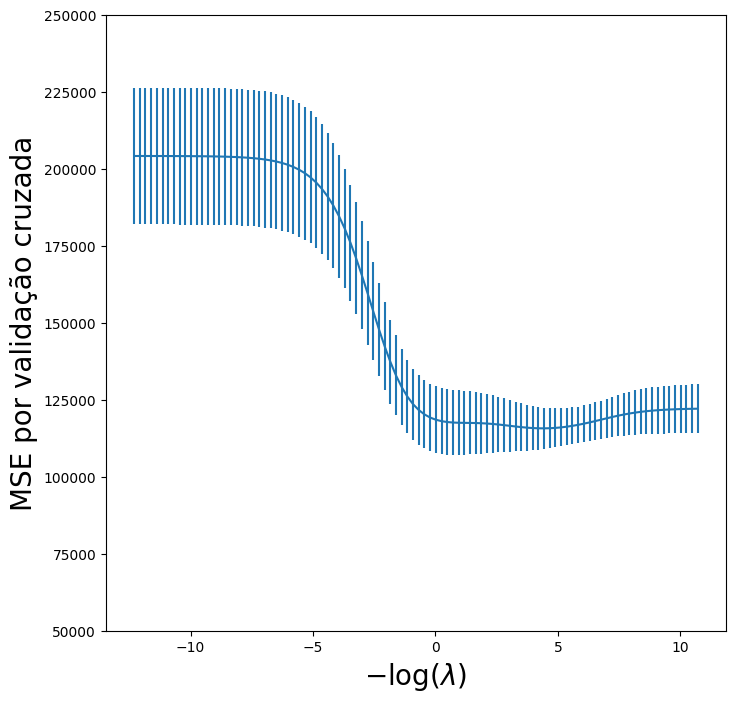

In [37]:
ridge_fig, ax = subplots(figsize=(8, 8))

ax.errorbar(
    -np.log(lambdas),
    -grid.cv_results_['mean_test_score'],
    yerr=grid.cv_results_['std_test_score'] / np.sqrt(K)
)

ax.set_ylim([50000, 250000])
ax.set_xlabel(r'$-\log(\lambda)$', fontsize=20)
ax.set_ylabel('MSE por validação cruzada', fontsize=20);

Também podemos escolher \(\lambda\) usando \(R^2\), que é a métrica padrão de alguns estimadores do `sklearn`.

c:\Users\daler\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.880e+07, tolerance: 3.759e+03
Linear regression models with a zero l1 penalization strength are more efficiently fitted using one of the solvers implemented in sklearn.linear_model.Ridge/RidgeCV instead.
  model = cd_fast.enet_coordinate_descent(
c:\Users\daler\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.101e+07, tolerance: 4.201e+03
Linear regression models with a zero l1 penalization strength are more efficiently fitted using one of th

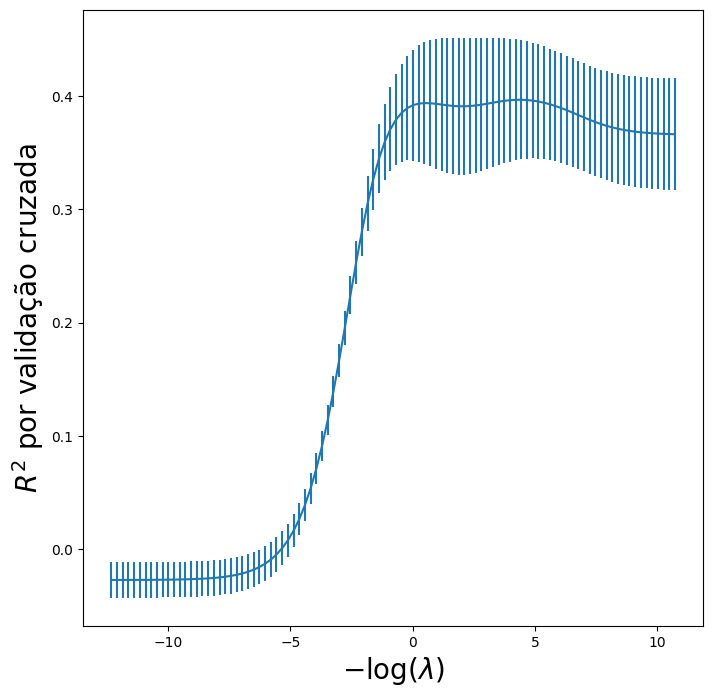

In [38]:
grid_r2 = skm.GridSearchCV(
    pipe,
    param_grid,
    cv=kfold
)

grid_r2.fit(X, Y)

r2_fig, ax = subplots(figsize=(8, 8))

ax.errorbar(
    -np.log(lambdas),
    grid_r2.cv_results_['mean_test_score'],
    yerr=grid_r2.cv_results_['std_test_score'] / np.sqrt(K)
)

ax.set_xlabel(r'$-\log(\lambda)$', fontsize=20)
ax.set_ylabel(r'$R^2$ por validação cruzada', fontsize=20);

## Validação cruzada rápida para caminhos de solução

Ridge, lasso e elastic net podem ser ajustados eficientemente ao longo de uma sequência de valores de \(\lambda\), formando um caminho de regularização.

In [39]:
ridgeCV = skl.ElasticNetCV(
    alphas=lambdas,
    l1_ratio=0,
    cv=kfold
)

pipeCV = Pipeline(
    steps=[
        ('scaler', scaler),
        ('ridge', ridgeCV)
    ]
)

pipeCV.fit(X, Y)

tuned_ridge = pipeCV.named_steps['ridge']

c:\Users\daler\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:701: UserWarning: Coordinate descent without L1 regularization may lead to unexpected results and is discouraged. Set l1_ratio > 0 to add L1 regularization.
  model = cd_fast.enet_coordinate_descent_gram(
c:\Users\daler\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.880e+07, tolerance: 3.759e+03
  model = cd_fast.enet_coordinate_descent_gram(
c:\Users\daler\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:701: UserWarning: Coordinate descent without L1 regularization may lead to unexpected results and is discouraged. Set l1_ratio > 0 to add L1 regularization.
  model = cd_fast

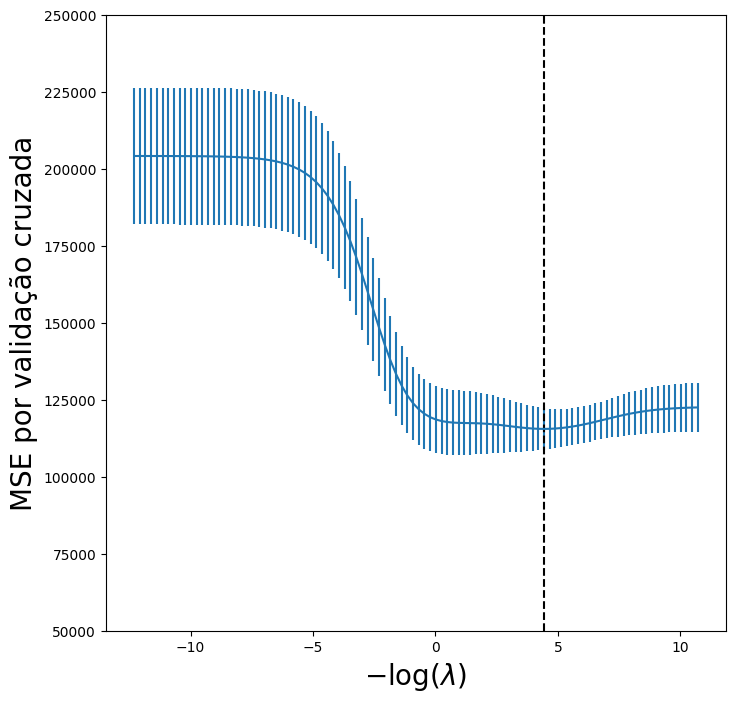

In [40]:
ridgeCV_fig, ax = subplots(figsize=(8, 8))

ax.errorbar(
    -np.log(lambdas),
    tuned_ridge.mse_path_.mean(1),
    yerr=tuned_ridge.mse_path_.std(1) / np.sqrt(K)
)

ax.axvline(-np.log(tuned_ridge.alpha_), c='k', ls='--')
ax.set_ylim([50000, 250000])
ax.set_xlabel(r'$-\log(\lambda)$', fontsize=20)
ax.set_ylabel('MSE por validação cruzada', fontsize=20);

In [41]:
tuned_ridge.alpha_, np.min(tuned_ridge.mse_path_.mean(1))

(np.float64(0.01185247763144249), np.float64(115526.70630987812))

Os coeficientes ajustados no conjunto completo ficam em `tuned_ridge.coef_`.

Como esperado, nenhum coeficiente é exatamente zero. Ridge não faz seleção de variáveis.

In [42]:
tuned_ridge.coef_

array([-222.80877051,  238.77246614,    3.21103754,   -2.93050845,
          3.64888723,  108.90953869,  -50.81896152, -105.15731984,
        122.00714801,   57.1859509 ,  210.35170348,  118.05683748,
       -150.21959435,   30.36634231,  -61.62459095,   77.73832472,
         40.07350744,  -25.02151514,  -13.68429544])

## Erro de teste da ridge escolhida por validação cruzada

Como a validação cruzada usa os dados para escolher \(\lambda\), fazemos uma divisão externa entre treino e teste. Dentro do treino, escolhemos \(\lambda\) por validação cruzada. Depois avaliamos no teste externo.

In [43]:
outer_valid = skm.ShuffleSplit(
    n_splits=1,
    test_size=0.25,
    random_state=1
)

inner_cv = skm.KFold(
    n_splits=5,
    shuffle=True,
    random_state=2
)

ridgeCV = skl.ElasticNetCV(
    alphas=lambdas,
    l1_ratio=0,
    cv=inner_cv
)

pipeCV = Pipeline(
    steps=[
        ('scaler', scaler),
        ('ridge', ridgeCV)
    ]
)

results = skm.cross_validate(
    pipeCV,
    X,
    Y,
    cv=outer_valid,
    scoring='neg_mean_squared_error'
)

-results['test_score']

c:\Users\daler\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:701: UserWarning: Coordinate descent without L1 regularization may lead to unexpected results and is discouraged. Set l1_ratio > 0 to add L1 regularization.
  model = cd_fast.enet_coordinate_descent_gram(
c:\Users\daler\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.600e+07, tolerance: 3.201e+03
  model = cd_fast.enet_coordinate_descent_gram(
c:\Users\daler\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:701: UserWarning: Coordinate descent without L1 regularization may lead to unexpected results and is discouraged. Set l1_ratio > 0 to add L1 regularization.
  model = cd_fast

array([132393.84003227])

## O lasso

Agora ajustamos lasso usando `ElasticNetCV()` com:

\[
\text{l1\_ratio} = 1
\]

O lasso pode produzir modelos mais interpretáveis porque alguns coeficientes podem ser exatamente zero.

In [44]:
lassoCV = skl.ElasticNetCV(
    n_alphas=100,
    l1_ratio=1,
    cv=kfold
)

pipeCV = Pipeline(
    steps=[
        ('scaler', scaler),
        ('lasso', lassoCV)
    ]
)

pipeCV.fit(X, Y)

tuned_lasso = pipeCV.named_steps['lasso']
tuned_lasso.alpha_

c:\Users\daler\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:1663: FutureWarning: 'n_alphas' was deprecated in 1.7 and will be removed in 1.9. 'alphas' now accepts an integer value which removes the need to pass 'n_alphas'. The default value of 'alphas' will change from None to 100 in 1.9. Pass an explicit value to 'alphas' and leave 'n_alphas' to its default value to silence this warning.
  warnings.warn(


np.float64(3.1472370031649866)

In [45]:
lambdas_lasso, soln_array = skl.Lasso.path(
    Xs,
    Y,
    n_alphas=100
)[:2]

soln_path = pd.DataFrame(
    soln_array.T,
    columns=D.columns,
    index=-np.log(lambdas_lasso)
)

soln_path.index.name = 'negative log(lambda)'

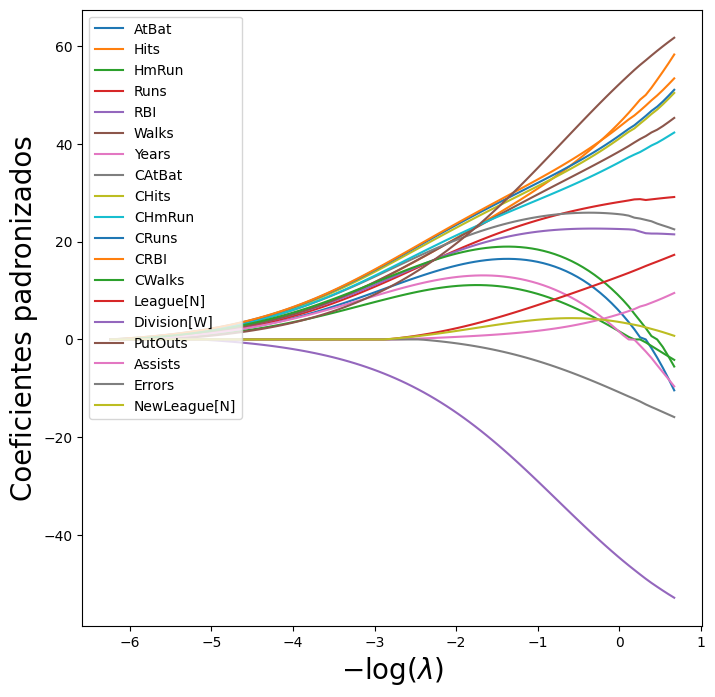

In [46]:
path_fig, ax = subplots(figsize=(8, 8))

soln_path.plot(ax=ax, legend=False)

ax.legend(loc='upper left')
ax.set_xlabel(r'$-\log(\lambda)$', fontsize=20)
ax.set_ylabel('Coeficientes padronizados', fontsize=20);

O menor erro médio de validação cruzada do lasso é próximo ao obtido por ridge.

In [47]:
np.min(tuned_lasso.mse_path_.mean(1))

np.float64(114690.73118253502)

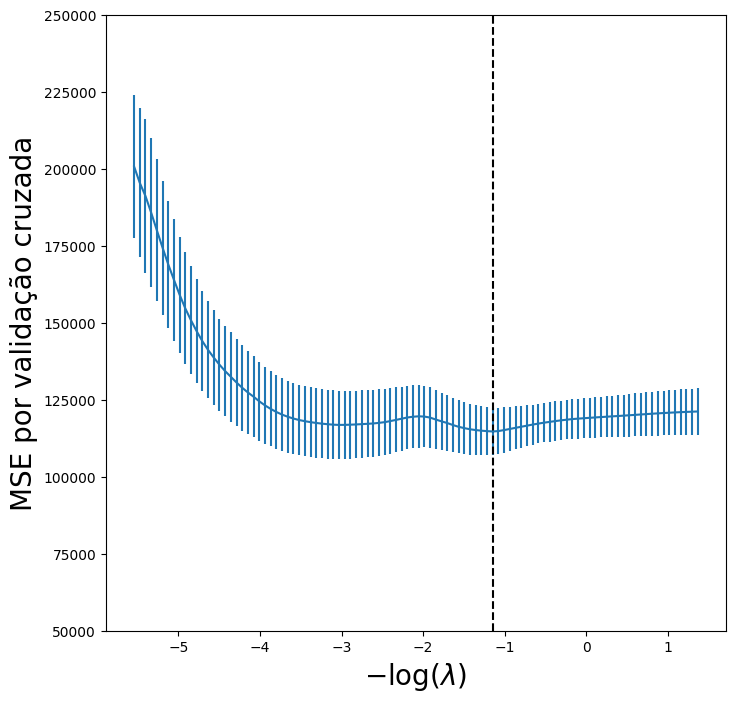

In [48]:
lassoCV_fig, ax = subplots(figsize=(8, 8))

ax.errorbar(
    -np.log(tuned_lasso.alphas_),
    tuned_lasso.mse_path_.mean(1),
    yerr=tuned_lasso.mse_path_.std(1) / np.sqrt(K)
)

ax.axvline(-np.log(tuned_lasso.alpha_), c='k', ls='--')
ax.set_ylim([50000, 250000])
ax.set_xlabel(r'$-\log(\lambda)$', fontsize=20)
ax.set_ylabel('MSE por validação cruzada', fontsize=20);

A vantagem do lasso aparece na esparsidade. No trecho do livro, 6 dos 19 coeficientes são zero, restando 13 variáveis no modelo.

In [49]:
coef_lasso = pd.Series(tuned_lasso.coef_, index=D.columns)

coef_lasso, (coef_lasso == 0).sum(), (coef_lasso != 0).sum()

(AtBat          -210.010088
 Hits            243.455031
 HmRun             0.000000
 Runs              0.000000
 RBI               0.000000
 Walks            97.693974
 Years           -41.522831
 CAtBat           -0.000000
 CHits             0.000000
 CHmRun           39.622982
 CRuns           205.752739
 CRBI            124.554566
 CWalks         -126.299868
 League[N]        15.702624
 Division[W]     -59.501580
 PutOuts          75.245900
 Assists          21.626980
 Errors          -12.044237
 NewLeague[N]     -0.000000
 dtype: float64,
 np.int64(6),
 np.int64(13))

# 6.5.3 Regressão PCR e PLS

Agora aplicamos regressão por componentes principais, PCR, e mínimos quadrados parciais, PLS.

## Regressão por componentes principais, PCR

A PCR pode ser feita com `PCA()` do módulo `sklearn.decomposition`.

O objetivo continua sendo prever `Salary` usando os dados `Hitters`.

Aqui usamos `LinearRegression()`, que ajusta intercepto por padrão.

In [50]:
pca = PCA(n_components=2)
linreg = skl.LinearRegression()

pipe = Pipeline(
    [
        ('pca', pca),
        ('linreg', linreg)
    ]
)

pipe.fit(X, Y)

pipe.named_steps['linreg'].coef_

array([0.09846131, 0.4758765 ])

Os resultados do PCA dependem da padronização. Por isso, incluímos `StandardScaler()` na pipeline.

In [51]:
pipe = Pipeline(
    [
        ('scaler', scaler),
        ('pca', pca),
        ('linreg', linreg)
    ]
)

pipe.fit(X, Y)

pipe.named_steps['linreg'].coef_

array([106.36859204,  21.60350456])

Escolhemos o número de componentes \(M\) por validação cruzada usando `GridSearchCV()`.

In [52]:
param_grid = {'pca__n_components': range(1, 20)}

grid = skm.GridSearchCV(
    pipe,
    param_grid,
    cv=kfold,
    scoring='neg_mean_squared_error'
)

grid.fit(X, Y)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...egression())])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'pca__n_components': range(1, 20)}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",KFold(n_split... shuffle=True)
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the sc

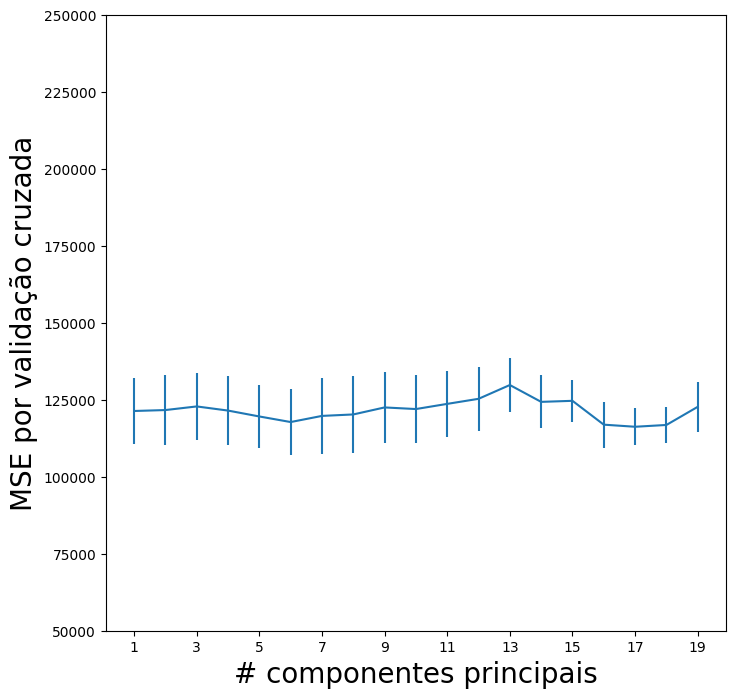

In [53]:
pcr_fig, ax = subplots(figsize=(8, 8))

n_comp = list(param_grid['pca__n_components'])

ax.errorbar(
    n_comp,
    -grid.cv_results_['mean_test_score'],
    grid.cv_results_['std_test_score'] / np.sqrt(K)
)

ax.set_ylabel('MSE por validação cruzada', fontsize=20)
ax.set_xlabel('# componentes principais', fontsize=20)
ax.set_xticks(n_comp[::2])
ax.set_ylim([50000, 250000]);

No trecho do livro, o menor erro de validação cruzada ocorre com 17 componentes. O gráfico também sugere que modelos com poucos componentes podem ter erro parecido.

Agora calculamos o MSE do modelo nulo, que usa apenas intercepto.

In [54]:
Xn = np.zeros((X.shape[0], 1))

cv_null = skm.cross_validate(
    linreg,
    Xn,
    Y,
    cv=kfold,
    scoring='neg_mean_squared_error'
)

-cv_null['test_score'].mean()

np.float64(204139.30692994667)

O atributo `explained_variance_ratio_` informa a proporção da variância dos preditores explicada por cada componente principal.

In [55]:
pipe.named_steps['pca'].explained_variance_ratio_

array([0.3831424 , 0.21841076])

No livro, \(M = 1\) captura cerca de 38,31% da variância; \(M = 2\) adiciona cerca de 21,84%, totalizando aproximadamente 60,15%. Com \(M = 6\), chega-se a cerca de 88,63%. Com todos os \(M = p = 19\) componentes, 100% da variância dos preditores é capturada.

## Mínimos quadrados parciais, PLS

O PLS é implementado por `PLSRegression()`.

Como no PCR, usamos validação cruzada para escolher o número de componentes.

In [56]:
pls = PLSRegression(
    n_components=2,
    scale=True
)

pls.fit(X, Y)

,"n_components n_components: int, default=2Number of components to keep. Should be in `[1, n_features]`.",2
,"scale scale: bool, default=TrueWhether to scale `X` and `y`.",True
,"max_iter max_iter: int, default=500The maximum number of iterations of the power method when`algorithm='nipals'`. Ignored otherwise.",500
,"tol tol: float, default=1e-06The tolerance used as convergence criteria in the power method: thealgorithm stops whenever the squared norm of `u_i - u_{i-1}` is lessthan `tol`, where `u` corresponds to the left singular vector.",1e-06
,"copy copy: bool, default=TrueWhether to copy `X` and `y` in :term:`fit` before applying centering,and potentially scaling. If `False`, these operations will be doneinplace, modifying both arrays.",True


In [57]:
param_grid = {'n_components': range(1, 20)}

grid = skm.GridSearchCV(
    pls,
    param_grid,
    cv=kfold,
    scoring='neg_mean_squared_error'
)

grid.fit(X, Y)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",PLSRegression()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'n_components': range(1, 20)}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",KFold(n_split... shuffle=True)
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displaye

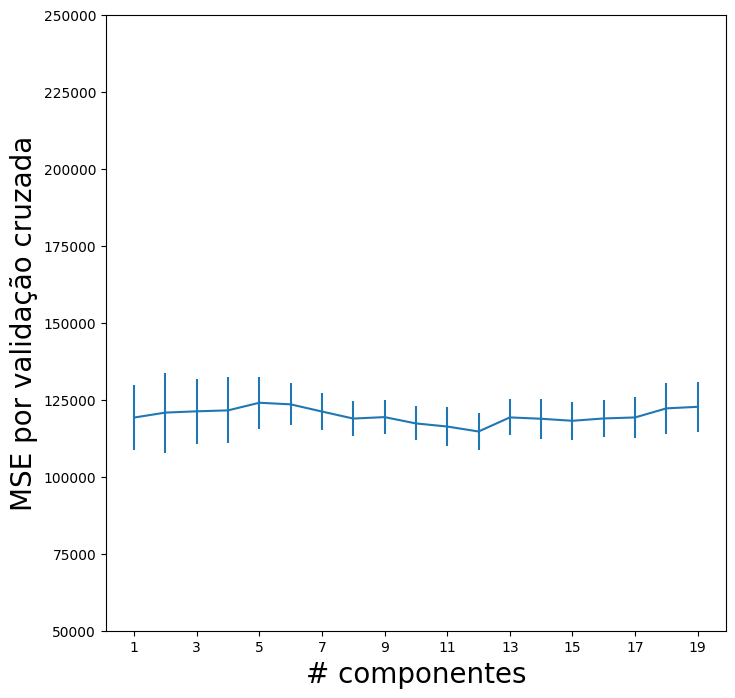

In [58]:
pls_fig, ax = subplots(figsize=(8, 8))

n_comp = list(param_grid['n_components'])

ax.errorbar(
    n_comp,
    -grid.cv_results_['mean_test_score'],
    grid.cv_results_['std_test_score'] / np.sqrt(K)
)

ax.set_ylabel('MSE por validação cruzada', fontsize=20)
ax.set_xlabel('# componentes', fontsize=20)
ax.set_xticks(n_comp[::2])
ax.set_ylim([50000, 250000]);

No trecho do livro, o erro de validação cruzada é minimizado em 12 componentes. Ainda assim, há pouca diferença visível entre esse ponto e modelos com apenas 2 ou 3 componentes.

Essa conclusão reforça a ideia central: métodos de redução de dimensão podem criar modelos mais compactos sem perda grande de desempenho.

# Fechamento

Este laboratório conecta a teoria do capítulo à implementação prática.

A seleção forward escolhe variáveis gradualmente. A seleção do melhor subconjunto busca combinações diretamente. Ridge reduz variância encolhendo coeficientes. Lasso encolhe e seleciona variáveis. PCR reduz a dimensão usando componentes principais. PLS reduz a dimensão usando também a resposta \(Y\).

Em todos esses métodos, a validação cruzada aparece como ferramenta central para escolher parâmetros como \(\lambda\) ou o número de componentes \(M\).